检测到颜色翻转（白墙黑路），正在自动修正...


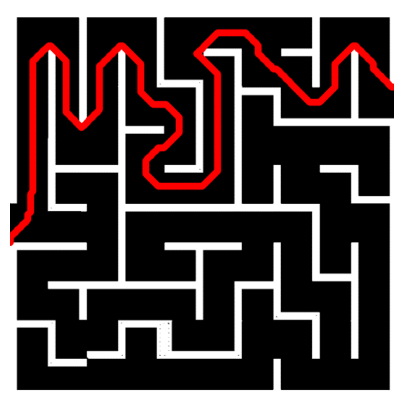

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq

class MazeSolverSmart:
    def __init__(self, img_path):
        self.img = cv2.imread(img_path)
        if self.img is None: raise ValueError("无法读取图片")
        
        # 1. 转灰度 + 二值化
        gray = cv2.cvtColor(self.img, cv2.COLOR_BGR2GRAY)
        # 使用 OTSU 自动寻找最佳阈值，适应性更强
        _, self.bin = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # --- [关键修改] 智能反色检测 ---
        # 逻辑：迷宫的四个角落通常是墙壁。
        # 如果角落大部分是白色(255)，说明墙是白的，路是黑的。
        # 但算法内部需要“白路黑墙”，所以需要反转。
        h, w = self.bin.shape
        corners = [self.bin[0,0], self.bin[0,w-1], self.bin[h-1,0], self.bin[h-1,w-1]]
        if np.mean(corners) > 127: 
            print("检测到颜色翻转（白墙黑路），正在自动修正...")
            self.bin = cv2.bitwise_not(self.bin) # 反转：变回黑墙白路
        
        # 膨胀修复微小断裂
        self.bin = cv2.dilate(self.bin, np.ones((3,3), np.uint8))
        self.path = []

    def solve(self, downsample_width=150, wall_penalty=10.0):
        h, w = self.bin.shape
        # 1. 自动找起终点 (边缘上的白点)
        mask = np.zeros_like(self.bin); cv2.rectangle(mask, (0,0), (w-1, h-1), 255, 1)
        border_pts = np.argwhere((self.bin == 255) & (mask == 255))
        if len(border_pts) < 2: 
            print("未找到起终点（可能迷宫边缘是封闭的？）")
            return False
        start, end = tuple(border_pts[0]), tuple(border_pts[-1])

        # 2. 降采样
        scale = min(1.0, downsample_width / w)
        sh, sw = int(h * scale), int(w * scale)
        small = cv2.resize(self.bin, (sw, sh), interpolation=cv2.INTER_AREA)
        _, small = cv2.threshold(small, 127, 255, cv2.THRESH_BINARY)

        # 3. 坐标映射 (防越界 + 自动吸附)
        valid_pts = cv2.findNonZero(small).squeeze()
        def get_closest(r, c):
            target = np.array([c * scale, r * scale]) 
            dists = np.sum((valid_pts - target)**2, axis=1)
            pt = valid_pts[np.argmin(dists)]
            return (pt[1], pt[0]) 

        s_small, e_small = get_closest(*start), get_closest(*end)

        # 4. A* 寻路
        dist = cv2.distanceTransform(small, cv2.DIST_L2, 5)
        dist = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
        
        pq, visited = [(0, s_small)], {}
        g_score = {s_small: 0}
        
        while pq:
            _, curr = heapq.heappop(pq)
            if curr == e_small: break
            if curr in visited: continue
            visited[curr] = True

            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
                nr, nc = curr[0] + dr, curr[1] + dc
                if 0 <= nr < sh and 0 <= nc < sw and small[nr, nc]:
                    cost = g_score[curr] + (1.414 if dr*dc else 1) + wall_penalty * (1 - dist[nr, nc])
                    if cost < g_score.get((nr, nc), float('inf')):
                        g_score[(nr, nc)] = cost
                        heur = ((nr - e_small[0])**2 + (nc - e_small[1])**2)**0.5
                        heapq.heappush(pq, (cost + heur, (nr, nc)))
                        self.path.append(((nr, nc), curr)) 

        # 5. 回溯
        path_map = dict(self.path)
        if e_small not in path_map and e_small != s_small: return False
        
        raw_path, curr = [], e_small
        while curr:
            raw_path.append((int(curr[0]/scale), int(curr[1]/scale)))
            curr = path_map.get(curr)
        
        self.path = [start] + raw_path[::-1] + [end]
        return True

    def visualize(self):
        if not self.path: return
        res = self.img.copy()
        pts = np.array([(p[1], p[0]) for p in self.path], np.int32).reshape((-1, 1, 2))
        cv2.polylines(res, [pts], False, (0, 0, 255), 8, cv2.LINE_AA)
        plt.figure(figsize=(8, 5)); plt.axis('off'); plt.imshow(res[...,::-1]); plt.show()

# --- 测试 ---
# 无论你传 maze_white_wall.png 还是 maze_black_wall.png，现在都能解
solver = MazeSolverSmart('real_maze4.png') 
if solver.solve():
    solver.visualize()